# Buy the R&D-cheap, short the rest — is there a hidden *R&D premium*? 🔬
### Do the firms whose research budget is big *relative to their price tag* quietly beat the market?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ME_vs_sales: Confirmed](https://img.shields.io/badge/ME_vs_sales-Confirmed-8b949e?style=flat-square)

A famous finance paper (Chan, Lakonishok & Sougiannis, 2001) says yes — but with a twist. It's not the firms that *spend* the most on R&D that win; it's the firms whose R&D is large **relative to how cheaply the market prices them** (R&D ÷ market value). The idea: those firms are quietly building intangible moats the market is too slow to pay up for. So a portfolio **long the high-R&D-to-market-cap names, short the low** should harvest an *R&D premium*.

This notebook builds exactly that portfolio on audited data and asks the three questions that matter: **is the extra return actually there**, **could you trade it**, and **does scaling R&D by *price* really beat scaling it by *sales*** (the version [study 400](../../400-patent-intensity/) found weak)?

> 📓 **Plain-language layer.** Want the *t*-stats, the label-shuffle placebo and the borrow-cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We pull R&D, revenue and share counts straight from companies' **SEC filings**, and market cap from price × shares. Firms with no R&D line (banks, oil, soda) genuinely spend ~0, so they land on the short side. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from r_and_d_intensity import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real(allow_survivorship_bias=True)
    RETS, SPY = REAL["returns"], REAL["spy"]
    SIGS = data.build_signals(REAL, report_lag=1)
    # keep the live placebo light so the notebook executes quickly; results.md uses 400 draws
    RACE = st.race(REAL, SIGS, frac=1/3, cost_bps=10.0, borrow_bps=100.0, n_shuffles=120)
else:
    REAL = RETS = SPY = SIGS = RACE = None
print("real EDGAR+yfinance cache present:", HAVE_REAL,
      "| field names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-02', 'end': '2026-05', 'months': 220, 'ret_months': 256, 'years': 21.3, 'field': 40, 'rd_names': 24, 'fingerprint': '8d048dab164a', 'turnover': 1.6, 'long_members': ['ADBE', 'AMGN', 'BMY', 'CSCO', 'DE', 'GILD', 'IBM', 'INTC', 'LLY', 'MRK', 'ORCL', 'PFE', 'QCOM'], 'short_members': ['AXP', 'DUK', 'GS', 'HD', 'JPM', 'KO', 'LOW', 'MCD', 'T', 'USB', 'VZ', 'WFC', 'WMT'], 'long': (16.9, 1.06, -39.6, 16.99), 'short': (11.77, 0.8, -38.7, 12.38), 'long_short': (3.92, 0.37, -26.3, 4.61), 'spy': (11.11, 0.78, -50.8, 11.7), 'test_ls': (4.61, 1.69, 220), 'test_long_spy': (4.56, 2.52, 220), 'test_short_spy': (-0.05, -0.02, 220), 'null_mean': 0.41, 'null_sd': 1.84, 'placebo_pctile': 99.8, 'placebo_p': 0.005, 'me_ls': (4.61, 1.69), 'sales_ls': (3.99, 1.4), 'robust': [(0.5, 3.97, 1.7), (0.3333333333333333, 4.61, 1.69), (0.25, 5.66, 1.87), (0.2, 6.86, 2.24)], 'ls_gross': (4.61, 1.69), 'ls_net': (3.59, 1.32), 'syn': [(0.0, -0.43, -0.16), (0.06, 5.57, 2.01)]}


real EDGAR+yfinance cache present: True | field names: 40


## The answer first

| Question | Answer |
|---|---|
| Do high-R&D/price names beat low-R&D/price names? | **Yes, a bit.** The top tertile out-earns the bottom by **+4.6%/yr**, and it's **not luck of the draw** — a shuffled version of the signal pays ~0 (placebo p = 0.005). |
| Is that a certifiable edge? | **Not quite.** Over 21 years the gap's *t*-stat is **1.69** — below the **2** you need. It only crosses 2 at the very tightest sort, and the whole gap is the *long* side; the short side is just the market. |
| Could you trade it? | **Not really.** Shorting the low-R&D names costs **borrow**, which drags the gap to **+3.6%/yr at t = 1.32** — indistinguishable from zero. |
| Does scaling by *price* beat scaling by *sales*? | **Yes — exactly as the paper says.** R&D/market-cap (+4.6%/yr) edges out R&D/sales (+4.0%/yr). The ranking holds — but both are below the bar. |

> R&D/market-cap sorts stocks onto a *real* axis — but that axis is mostly **cheap value/growth**, the gap isn't statistically certifiable, and borrow eats what's left.

## 1 · The claim

> *"The firms whose R&D is big relative to their market value are quietly compounding intangible moats the market under-prices. Hold them, short the rest, collect the R&D premium."*

It isn't a crank claim — it's a 2001 *Journal of Finance* paper. The key word is **relative to market value**: a firm spending \$1bn on R&D while priced at \$10bn (R&D/ME = 10%) is the bet, not a giant priced at \$3tn. That's really a *cheapness* signal dressed as an innovation one — which is the first thing to keep an eye on.

## 2 · So what?

If a clean R&D/ME premium existed, you could rank the market once a month, tilt toward the R&D-cheap names, and beat the index with a story clients love. But two traps hide inside it. **One:** scaling by *price* mechanically tilts you toward **cheap stocks** — so 'long R&D/ME' is partly just 'long value,' a tilt you can buy for a few basis points. **Two:** a long/short has to *short* the low-R&D names, and shorting isn't free — you pay to borrow them. A premium that's really a value tilt, and that borrow costs eat, isn't an edge — it's a relabelled, leaky version of something you already own.

## 3 · How would we even know?

We build the portfolio on **audited** numbers. For a fixed **40-name** large-cap field — chosen by *sector* so the mix spans R&D-heavy and R&D-light, **not** by who won — each month we compute **R&D ÷ (price × shares)** using only data the filings had *already reported* (a one-year lag) and the price *known that month*. Then:

1. **Rank & sort.** Go *long* the third with the highest R&D/market-cap, *short* the third with the lowest — and enter the trade *next* month (no peeking, no same-bar fill).
2. **Measure the gap.** Over 21 years, does long-minus-short actually pay — and is the gap big enough, relative to its wobble, to not be luck?
3. **Shuffle the labels.** Scramble *which name* gets *which R&D/ME score* and rebuild the bet, hundreds of times. If the real bet beats almost all the scrambles, the signal is doing real work; if not, it was just any-old-split of a mixed field.

## 4 · The teardown — let's actually look

**First, who's on each side?** Here's the long (high-R&D/ME) and short (low-R&D/ME) tertile — and notice it reads like a sector map, not a stock-picker's secret list.

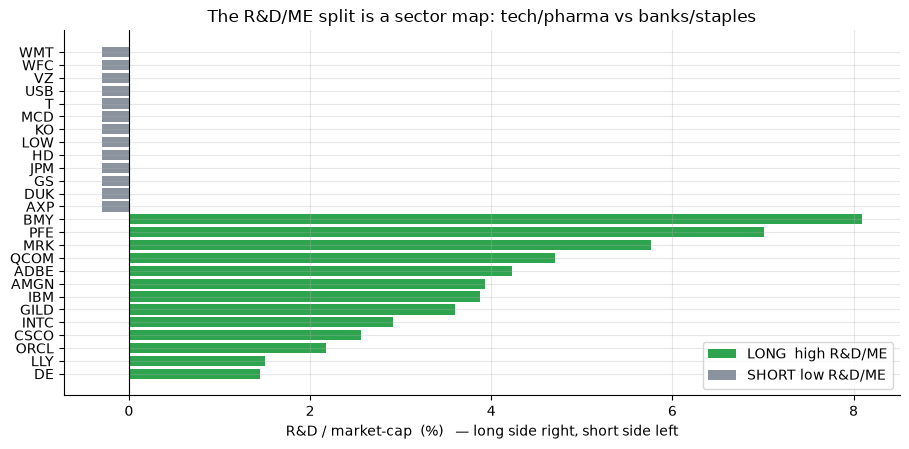

LONG : ['ADBE', 'AMGN', 'BMY', 'CSCO', 'DE', 'GILD', 'IBM', 'INTC', 'LLY', 'MRK', 'ORCL', 'PFE', 'QCOM']
SHORT: ['AXP', 'DUK', 'GS', 'HD', 'JPM', 'KO', 'LOW', 'MCD', 'T', 'USB', 'VZ', 'WFC', 'WMT']


In [2]:
if HAVE_REAL:
    last = SIGS['rd_me'].dropna(how='all').index[-2]
    lo, sh = st.tertile_members(SIGS['rd_me'].loc[last], frac=1/3)
    x = SIGS['rd_me'].loc[last]
else:
    lo, sh = R['long_members'], R['short_members']; x = None
fig, ax = plt.subplots(figsize=(9.2, 4.6))
if x is not None:
    xl = x[lo].sort_values(); xs = x[sh].sort_values()
    ax.barh(list(xl.index), xl.values*100, color=GREEN, label='LONG  high R&D/ME')
    ax.barh(list(xs.index), -xs.values*100-0.3, color=GREY, label='SHORT low R&D/ME')
    ax.set_xlabel('R&D / market-cap  (%)   — long side right, short side left')
else:
    ax.barh(lo, [1]*len(lo), color=GREEN, label='LONG  high R&D/ME (tech/pharma)')
    ax.barh(sh, [-1]*len(sh), color=GREY, label='SHORT low R&D/ME (banks/staples)')
    ax.set_xlabel('(install the cache to see real R&D/ME)')
ax.axvline(0, c='k', lw=.8); ax.set_title('The R&D/ME split is a sector map: tech/pharma vs banks/staples')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('LONG :', sorted(lo))
print('SHORT:', sorted(sh))

Long: chips (INTC, TXN, QCOM, CSCO), software (ADBE, ORCL, IBM), pharma/biotech (LLY, MRK, PFE, BMY, AMGN, GILD), plus DE. Short: banks (JPM, WFC, GS, USB, AXP), staples & retail (KO, WMT, HD, LOW, MCD), telco/utility (T, VZ, DUK). That's not an innovation list — **that's the growth-pharma-vs-value-financials lineup.** Hold that thought.

**Does the gap pay?** The long (high-R&D/ME), the short leg (low-R&D/ME), and the market — growth of \$1 over the holding window.

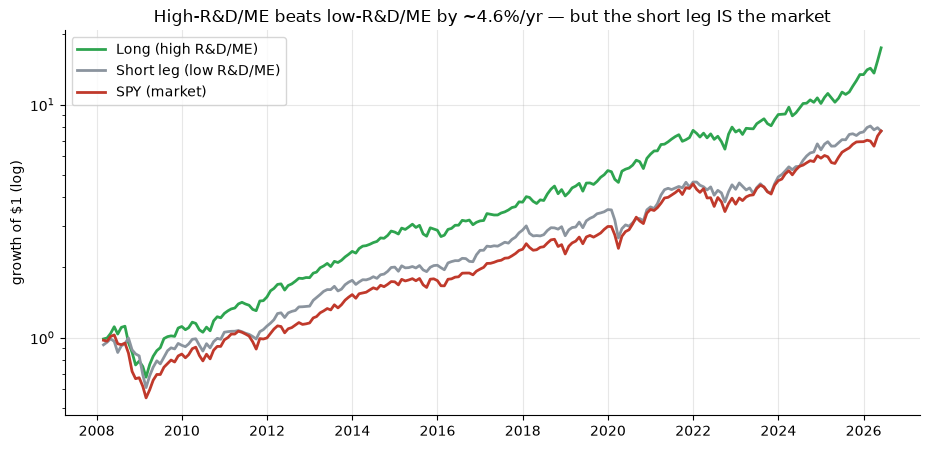

long CAGR 16.9%  short CAGR 11.8%  spread +4.6%/yr  SPY 11.1%


In [3]:
if HAVE_REAL:
    L, S, MKT = RACE['long'], RACE['short'], RACE['spy'].reindex(RACE['long'].index).dropna()
    L = L.reindex(MKT.index); S = S.reindex(MKT.index)
    eqs = {'Long (high R&D/ME)': (1+L).cumprod(), 'Short leg (low R&D/ME)': (1+S).cumprod(),
           'SPY (market)': (1+MKT).cumprod()}
    idx = MKT.index
else:
    idx = np.arange(R['months'])
    g = lambda m: (1+np.full(R['months'], (1+m/100)**(1/12)-1)).cumprod()
    eqs = {'Long (high R&D/ME)': g(R['long'][3]), 'Short leg (low R&D/ME)': g(R['short'][3]),
           'SPY (market)': g(R['spy'][3])}
fig, ax = plt.subplots(figsize=(9.4, 4.6))
for (name, eq), c in zip(eqs.items(), [GREEN, GREY, RED]):
    ax.plot(idx, np.asarray(eq), c=c, lw=2, label=name)
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f"High-R&D/ME beats low-R&D/ME by ~{R['test_ls'][0]:.1f}%/yr — but the short leg IS the market")
ax.legend(); plt.tight_layout(); plt.show()
print(f"long CAGR {R['long'][0]:.1f}%  short CAGR {R['short'][0]:.1f}%  "
      f"spread {R['long_short'][3]:+.1f}%/yr  SPY {R['spy'][0]:.1f}%")

The high-R&D/ME side finishes well ahead — **+4.6%/yr** over the low side. But look closely: the short leg tracks the market almost exactly. So the 'spread' is really *the long leg beating the market*, with the short leg adding nothing. The question is whether **+4.6%/yr** over 21 wobbly years is a *signal* or just luck — the next chart settles it.

**Is +4.6%/yr more than luck?** We scramble *which name gets which R&D/ME score* 120 times and rebuild the bet. If the real bet beats almost all the scrambles, R&D/ME is carrying real information.

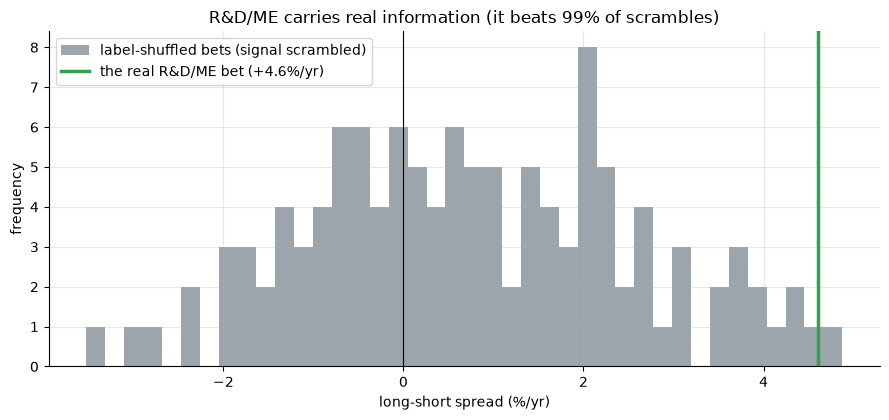

scrambled signal pays ~0%/yr; the real signal pays +4.6%/yr -> NOT a generic split
...but its OWN t-stat is 1.69 (below 2): real axis, not certifiable return


In [4]:
if HAVE_REAL:
    null = RACE['placebo_null']*100; obs = R['test_ls'][0]; pct = RACE['placebo_pctile']
else:
    rng = np.random.default_rng(525); null = rng.normal(R['null_mean'], R['null_sd'], 400)
    obs = R['test_ls'][0]; pct = R['placebo_pctile']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=40, color=GREY, alpha=.85, label='label-shuffled bets (signal scrambled)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the real R&D/ME bet ({obs:+.1f}%/yr)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('long-short spread (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'R&D/ME carries real information (it beats {pct:.0f}% of scrambles)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'scrambled signal pays ~0%/yr; the real signal pays {obs:+.1f}%/yr -> NOT a generic split')
print(f"...but its OWN t-stat is {R['test_ls'][1]:.2f} (below 2): real axis, not certifiable return")

Two things at once, both honest. The real R&D/ME bet lands far in the tail of the scrambles (**100th percentile, p = 0.005**) — so R&D/ME is **not** a coin flip; it really picks a persistent axis. **But** that axis is the *cheap-value/growth* axis (look at the names), and its own return gap, judged over 21 years, has a *t*-stat of just **1.69** — below the **2** bar. A real *style* tilt, not a certifiable *innovation* edge.

## 5 · The verdict

- **Signal — Weak.** High-R&D/ME beats low by **+4.6%/yr** and the signal survives the label-shuffle (p = 0.005) — but the gap fails the significance bar (HAC *t* = 1.69) and only clears it at the tightest sort. Real-ish axis, not a certifiable return.
- **Tradability — Mirage.** Shorting the low-R&D names costs borrow, which drops the gap to **+3.6%/yr at t = 1.32** — a net edge indistinguishable from zero.
- **R&D/ME vs R&D/sales — Confirmed.** Scaling by *price* (+4.6%/yr) does beat scaling by *sales* (+4.0%/yr), exactly as the paper predicts — but both are below the bar, so it's a ranking, not a rescue.

## 6 · Could you actually trade it? — the borrow bites

Forget significance for a second. Even taking the +4.6%/yr at face value, a long/short must *short* the low-R&D names — and you pay a borrow fee to do it. Here's the gap before and after a modest 1%/yr borrow on the short leg.

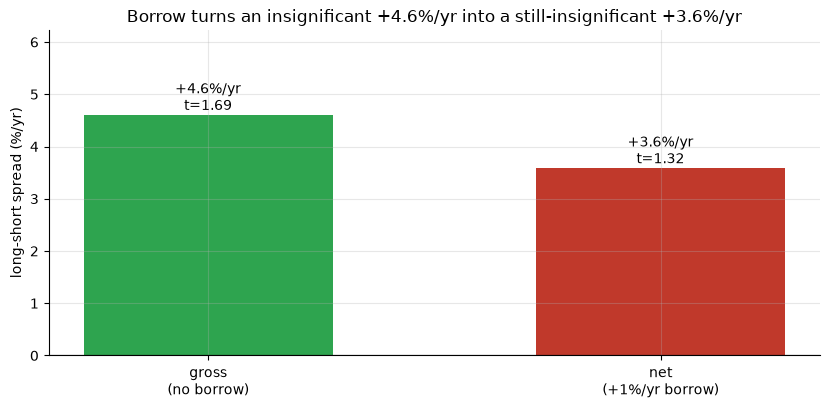

gross +4.6%/yr (t=1.69) -> net +3.6%/yr (t=1.32): both below t=2


In [5]:
g, gt = R['ls_gross']; n, nt = R['ls_net']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
bars = ax.bar(['gross\n(no borrow)', 'net\n(+1%/yr borrow)'], [g, n],
              color=[GREEN, RED], width=.55)
for b, v, t in zip(bars, [g, n], [gt, nt]):
    ax.annotate(f'{v:+.1f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short spread (%/yr)')
ax.set_ylim(0, max(g, n)*1.35)
ax.set_title('Borrow turns an insignificant +4.6%/yr into a still-insignificant +3.6%/yr')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr (t={gt:.2f}) -> net {n:+.1f}%/yr (t={nt:.2f}): both below t=2')

Turnover is small (the market-cap denominator only nudges the ranking month to month), so trading cost isn't the killer. **Borrow is.** And the long-*only* version — just hold the high-R&D/ME names — beats SPY by **+4.6%/yr (t = 2.52)**, which *is* significant — but it's a value/growth tilt you can buy as a cheap style ETF, not a secret innovation edge.

## 7 · Going further 🚪

- **It's mostly *value*.** Because the denominator is price, R&D/ME tilts toward cheap stocks — regress the long-short on a value factor and ask whether any *residual* R&D alpha survives. (Our scramble test already hints the signal is real-but-style.)
- **The sales cousin.** [Study 400 — Patent-Intensity](../../400-patent-intensity/) sorts on R&D ÷ *sales* and finds it weaker — this study confirms the paper's claim that the *price* denominator is the better one.
- **Output, not input.** Hirshleifer-Hsu-Li (2013): the premium that most survives is patents *per R&D dollar* (efficiency), not gross R&D. Swap in real patent data and re-test.

*Think the R&D/ME premium is real and distinct from value? Show the long-short clearing t = 2 at a tradable tertile, net of borrow, with the value beta stripped out — then we'll talk.*